# V0.5分析用ファイル

```py
colabでの構成

plt.ipynb
       |___xxx.json
       |___my_plot.py
```


| 階層1 (トップレベル) | 階層2 (`steps`内) | 階層3 (詳細) | 記録されている内容 |
| :--- | :--- | :--- | :--- |
| `configuration` | | | ゲームの設定値（最大ターン数720、初期資金3000、ボードサイズなど） |
| `info` | | | 対戦プレイヤーの名前（"nk"さん、"大山"さん）やシード値 |
| `rewards` | | | 最終的なスコア（所持金） |
| `steps` | | | ターンごとの全記録が入ったリスト（分析において最も重要） |
| | `action` | | そのターンにプレイヤーが送ったコマンド |
| | | `farmer` | メイン農家の行動（例: `["PLANT", "WHEAT"]` など） |
| | | `hands` | 労働者たちの行動リスト |
| | | `market` | 市場での売買・雇用アクション（例: `["BUY_SEED", "WHEAT", 1]`, `["HIRE"]` など） |
| | `observation` | | そのターンのゲーム内の全状況 |
| | | `step` / `day` / `hour` | 現在の進行度（何日目の何時間目か） |
| | | `market` | 市場の状況（`prices`: 現在の価格、`inventory`: 市場の在庫数） |
| | | `farms` | プレイヤー0と1（敵）の農場状態（`money`: 所持金、`tiles`: 10x10のマス目の状態、`farmer` / `hands`: 座標、`hires_today`: 今日の雇用人数） |
| | | `private` | 自分だけが見える非公開情報（`shed`: 小屋の収穫物在庫、`seeds`: 所持している種の数） |
| | | `town` | 町の状況（`unlocked_shops`: 解放されているショップのリスト） |
| | `reward` | | その時点でのスコア（所持金と同値） |
| | `status` | | エラー落ちしていないか（"ACTIVE" または "DONE"） |


ライブラリのインストール完了...


json file 90144571.json を読み込み完了...


 下記が【90144571.json】 のDataFrameです☆




     step  p0_money  wheat_price  melon_price  wheat_in_shed  melon_in_shed  \
0       1    2989.0           26          256              0              0   
1       2    2989.0           26          256              0              0   
2       3    2979.0           26          256              0              0   
3       4    2979.0           26          256              0              0   
4       5    2979.0           26          256              0              0   
..    ...       ...          ...          ...            ...            ...   
714   715    6323.0           49          293              0              0   
715   716    6323.0           49          293              0              0   
716   717    6323.0           49          293              0              0   
717   718    6323.0           49          293              0              0   
718   719    6323.0           49   

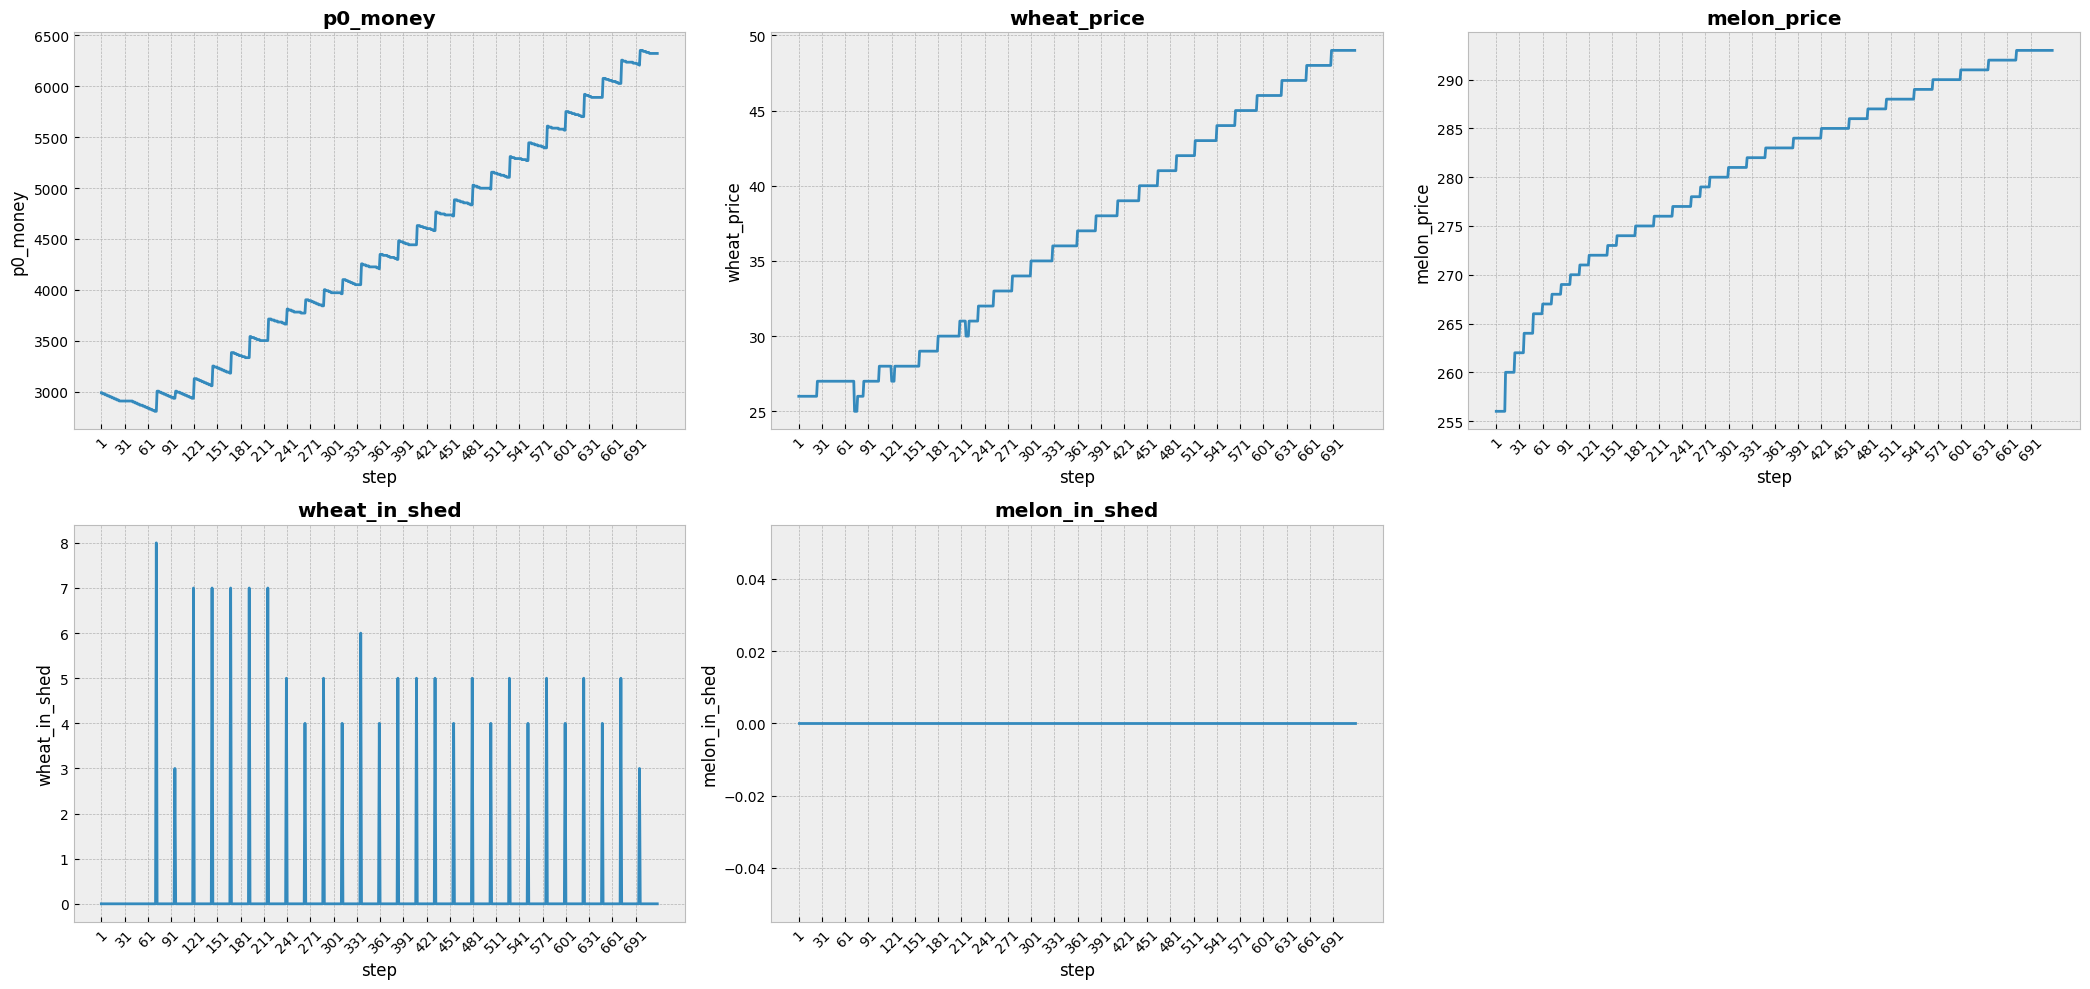

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns
import numpy as np
from my_plot import sns_line_s

print("""
ライブラリのインストール完了...
""")


file='90144571.json'

with open(file, 'r') as f:
    log = json.load(f)

print(f"""
json file {file} を読み込み完了...
""")


data_list = []

for i, step in enumerate(log['steps']):
    if i == 0: continue

    # プレイヤー0（勝者と仮定）のデータと市場データを取得
    obs = step[0]['observation']
    market_prices = obs['market']['prices']
    p0_money = obs['farms'][0]['money']


    # プレイヤー0のマーケットアクション（売買履歴）
    p0_market_action = step[0]['action'].get('market', [])

    # 小屋の在庫（ホールドしている数）
    p0_shed = obs['private']['shed']

    # データを1行にまとめる

    row = {

        'step': i,
        'p0_money': p0_money,
        'wheat_price': market_prices.get('WHEAT', 0),
        'melon_price': market_prices.get('MELON', 0),
        'wheat_in_shed': p0_shed.get('WHEAT', 0),
        'melon_in_shed': p0_shed.get('MELON', 0),
        'market_action': str(p0_market_action) if p0_market_action else ""
    }

    data_list.append(row)
    df = pd.DataFrame(data_list)

print(f"""
 下記が【{file}】 のDataFrameです☆



 ==============================================

{df}

 ==============================================




分析用json file【{file}】column一覧です

{df.columns.tolist()}

{df.columns.tolist()[0]}:ステップ数
{df.columns.tolist()[1]}:プレイヤー0の所持金
{df.columns.tolist()[2]}:'WHEAT'の値段
{df.columns.tolist()[3]}:'MELON'の値段
{df.columns.tolist()[4]}:'WHEAT'の小屋の在庫
{df.columns.tolist()[5]}:'MELON'小屋の在庫




""")


print("""


グラフを描画しています...


""")

cols_to_plot = [
    'p0_money',
    'wheat_price',
    'melon_price',
    'wheat_in_shed',
    'melon_in_shed'
]


sns_line_s(df, x='step', y=cols_to_plot, step=30)

